# Level 2 — Spatial Context: Mapping the Glioma Microenvironment

## CAJAL "Neuromics 2026" — Computational Mini-Project C10 (Level 2)

**Estimated time:** ~2.5 days

**Learning objectives**
- Load, QC, and explore Visium spatial transcriptomics data
- Get a first ("naive") spatial domain map directly from spot expression, before any deconvolution
- See the malignant cell-state axis directly in space, even before deconvolving spots
- Map your Level 1 reference onto tissue with **cell2location**
- Identify spatial niches (tissue domains) from the deconvolved cell-state map
- Quantify spatial organization: neighborhood enrichment, a proximity network, and spatial intermixing
- Compare your own results to the published figures (the paper is revealed in this notebook)

**Dataset:** Visium spatial transcriptomics from the **same two donors** as Level 1 — `AT10`
(primary, full feature set) and `AT14` (optional secondary section). Each spot covers
multiple cells (~1-10), so spot expression is a *mixture*, unlike Level 1's single nuclei.

> The paper is still not named yet. You'll recognize the cell-type and cell-state language
> from Level 1 — that continuity is the point. The reveal happens partway through this notebook.

---

## 0. Setup

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/src")
from gbmspace_utils.analysis import (
    MALIGNANT_AXIS_MARKERS, ZONATION_PANEL, score_axis, spatial_proximity_network,
)
from gbmspace_utils.plotting import plot_gene_on_tissue, plot_spatial_categories

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(5, 4))
%matplotlib inline

print("scanpy", sc.__version__, "| squidpy", sq.__version__)

/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
<cell 2>:21: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
scanpy 1.11.5 | squidpy 1.8.2


## 1. Load and explore the spatial data

🔬 **TASK 1.1:** Load the AT10 Visium section and inspect the object — note how it differs from Level 1's AnnData (spatial coordinates, a tissue image, no per-nucleus QC metrics yet).

In [4]:
VISIUM = "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/data/visium/level2_prepared/AT10-BRA-5-FO-1_2_student.h5ad"
adata = sc.read_h5ad(VISIUM)
print(adata)
print(f"\n{adata.n_obs} spots x {adata.n_vars} genes")
print(f".obsm: {list(adata.obsm.keys())}  |  .uns: {list(adata.uns.keys())}")
lib_id = list(adata.uns["spatial"].keys())[0]
print(f"Library: {lib_id}, images: {list(adata.uns['spatial'][lib_id]['images'].keys())}")

AnnData object with n_obs × n_vars = 3999 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'sample_name'
    var: 'feature_types'
    uns: 'spatial'
    obsm: 'spatial'

3999 spots x 36601 genes
.obsm: ['spatial']  |  .uns: ['spatial']
Library: AT10-BRA-5-FO-1_2, images: ['hires', 'lowres']


In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
sq.pl.spatial_scatter(adata, color=None, ax=ax, size=1.3)
ax.set_title(f"{lib_id} — H&E + spot grid ({adata.n_obs} spots)")

❓ **QUESTION:** Each Visium spot is ~55 µm in diameter. Given typical nucleus/cell sizes, roughly how many cells might a single spot cover? What does that imply about interpreting any single spot's gene expression?

## 2. Spatial quality control

Same idea as Level 1 — total counts, genes detected, %mito — but spots, not nuclei, and no doublet score (a "doublet" concept doesn't apply the same way to multi-cell spots).

🔬 **TASK 2.1:** Compute QC metrics and look at their distributions.

In [8]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
print(adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe().round(1))

       total_counts  n_genes_by_counts  pct_counts_mt
count        3999.0             3999.0         3999.0
mean        17273.7             5609.8            7.4
std          7994.7             1772.3            4.6
min            10.0               10.0            0.0
25%         11531.0             4567.5            4.5
50%         17271.0             5901.0            6.2
75%         22751.5             6916.0            8.8
max         54333.0             9977.0           30.6


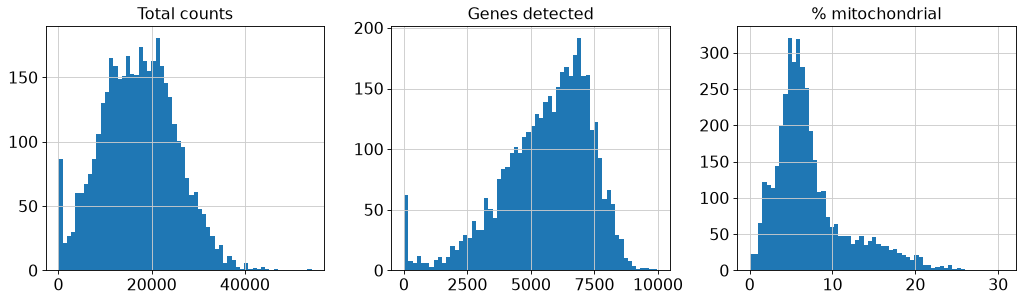

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(adata.obs["total_counts"], bins=60); axes[0].set_title("Total counts")
axes[1].hist(adata.obs["n_genes_by_counts"], bins=60); axes[1].set_title("Genes detected")
axes[2].hist(adata.obs["pct_counts_mt"], bins=60); axes[2].set_title("% mitochondrial")
plt.tight_layout(); plt.show()

💡 **HINT:** Visium spots are much "deeper" than single nuclei (each spot pools several cells), so don't reuse Level 1's per-nucleus thresholds verbatim — look at *these* distributions. A light touch is usually right: drop near-empty spots (very low counts/genes), keep almost everything else.

🔬 **TASK 2.2:** Apply QC and a minimum-cells gene filter. Report spots/genes remaining.

In [11]:
n0 = adata.n_obs
adata = adata[(adata.obs["total_counts"] >= 500) & (adata.obs["n_genes_by_counts"] >= 250)].copy()
sc.pp.filter_genes(adata, min_cells=3)
print(f"Spots: {n0} -> {adata.n_obs}")
print(f"Genes (min_cells=3): {adata.n_vars}")

Spots: 3999 -> 3928
Genes (min_cells=3): 24573


⚠️ **CHECKPOINT:** This section should remove very few spots — on the order of **1-2% of spots** (this dataset is high quality; expect roughly **3,900-3,950 spots** remaining out of ~4,000, and somewhere around **24,000-25,000 genes** after the gene filter). If you lost a large fraction of spots, your thresholds are too strict for Visium-scale counts.

## 3. Normalization and a *naive* spatial domain map

Before any deconvolution, let's see what plain clustering of spot expression gives us — a "naive" map of spatial domains, mixing whatever cell types happen to co-occur in each spot.

🔬 **TASK 3.1:** Normalize, log-transform, select HVGs, and run PCA.

/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


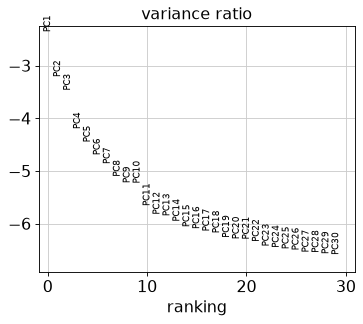

In [14]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", layer="counts")
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=30)
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.uns["pca"] = adata_hvg.uns["pca"]
sc.pl.pca_variance_ratio(adata, n_pcs=30, log=True)

🔬 **TASK 3.2:** Build the neighbor graph, UMAP, and cluster at a couple of resolutions. Pick one.

In [16]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
for res in [0.5, 1.0]:
    sc.tl.leiden(adata, resolution=res, key_added=f"leiden_r{res}", flavor="igraph", n_iterations=2)
    print(f"resolution {res}: {adata.obs[f'leiden_r{res}'].nunique()} naive domains")
adata.obs["leiden"] = adata.obs["leiden_r1.0"]

resolution 0.5: 11 naive domains
resolution 1.0: 18 naive domains


💡 At resolution 0.5 you should see roughly **10-12** domains; at 1.0, roughly **16-20**. We carry resolution 1.0 forward as `leiden` — finer domains are easier to relate to the cell-state axis later, but feel free to use 0.5 instead.

🔬 **TASK 3.3:** Plot the naive domains both on the tissue and on UMAP, side by side.

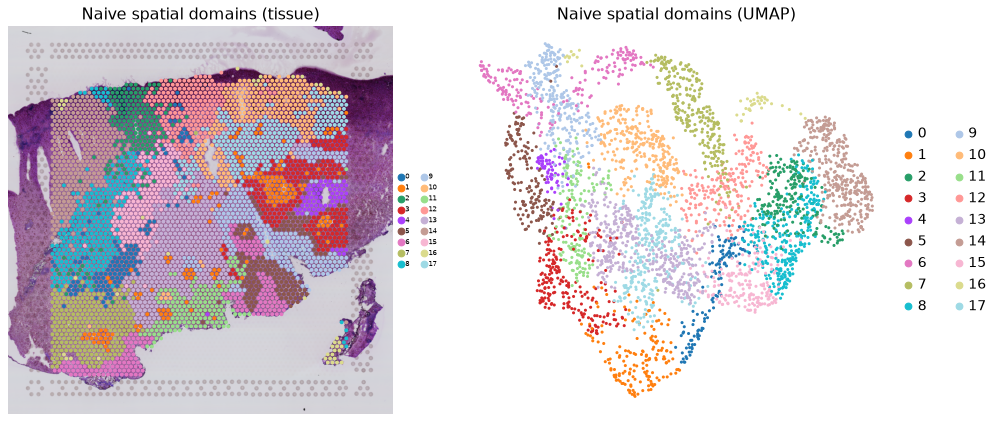

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sq.pl.spatial_scatter(adata, color="leiden", ax=axes[0], size=1.3, legend_fontsize=6)
axes[0].set_title("Naive spatial domains (tissue)")
sc.pl.umap(adata, color="leiden", ax=axes[1], show=False, title="Naive spatial domains (UMAP)")
plt.tight_layout(); plt.show()

❓ **QUESTION:** Do the naive domains form spatially coherent regions (contiguous patches of one color), or are they speckled/scattered across the tissue? What would each pattern imply about whether expression-based clustering alone is picking up real tissue architecture?

## 4. The malignant cell-state axis, in space (before deconvolution)

Level 1's marker-gene scoring works the same way here — `score_genes` doesn't care whether
an observation is a nucleus or a multi-cell spot. The catch: a spot's score is a *blend* of
whatever cell states happen to be in that spot, not a clean call.

🔬 **TASK 4.1:** Score every spot against the Level 1 malignant-state marker sets, using the shared `score_axis()` helper.

In [21]:
state_scores = score_axis(adata, MALIGNANT_AXIS_MARKERS, use_raw=True)
for col in state_scores.columns:
    adata.obs[f"score_{col}"] = state_scores[col].values
print(adata.obs.groupby("leiden")[[f"score_{c}" for c in state_scores.columns]].mean().round(3))

<cell 21>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
        score_OPC-like  score_OPC-NPC-like  ...  score_Hypoxic  score_Proliferative
leiden                                      ...                                    
0               -0.018               0.057  ...         -0.384               -0.004
1               -0.250              -0.198  ...         -0.089               -0.029
2                0.045               0.069  ...         -0.425               -0.042
3               -0.265              -0.192  ...          0.008               -0.029
4               -0.288              -0.220  ...          0.336               -0.040
5               -0.320              -0.286  ...          0.515               -0.061
6               -0.336              -0.276  ...          0.846               -0

🔬 **TASK 4.2:** Plot the paper's minimal 4-gene spatial zonation panel (`ZONATION_PANEL`: dev-like → gliosis → hypoxia) directly on tissue.

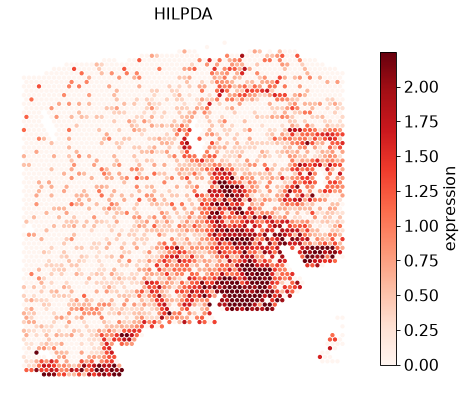

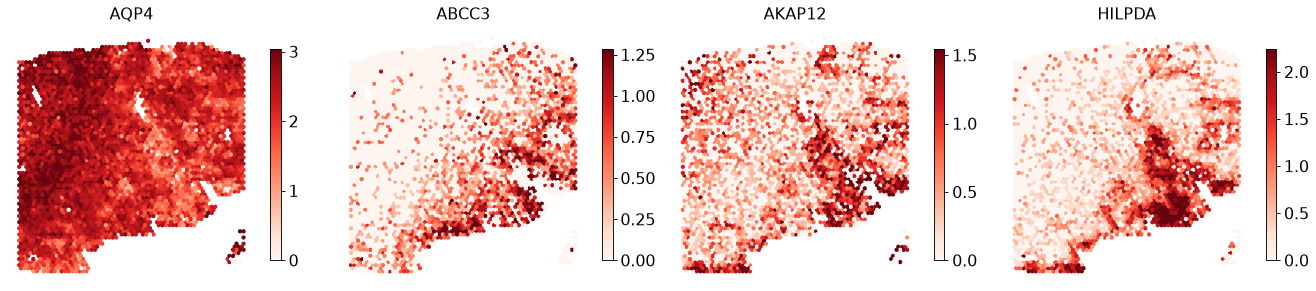

In [23]:
present = [g for g in ZONATION_PANEL if g in adata.raw.var_names]
fig, axes = plt.subplots(1, len(present), figsize=(4.2 * len(present), 4.2))
for ax, gene in zip(axes, present):
    plot_gene_on_tissue(adata, gene, spatial_key="spatial")  # see gbmspace_utils.plotting
plt.tight_layout(); plt.show()

fig2, axes2 = plt.subplots(1, len(present), figsize=(4.2 * len(present), 4.2))
for ax, gene in zip(axes2, present):
    expr = np.asarray(adata[:, gene].X.todense()).flatten()
    sca = ax.scatter(adata.obsm["spatial"][:, 0], adata.obsm["spatial"][:, 1], c=expr, cmap="Reds", s=8,
                      vmax=np.percentile(expr[expr > 0], 95) if (expr > 0).any() else None)
    ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_title(gene); ax.axis("off")
    fig2.colorbar(sca, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

❓ **QUESTION:** Do you see any spatial gradient across the four zonation genes — e.g. do `AQP4`-high and `HILPDA`-high regions occupy *different, non-overlapping* areas of the tissue? Compare this to the per-cluster axis scores above. This blended, spot-level picture is exactly the limitation **cell2location** is designed to address — keep this figure in mind for comparison once you've deconvolved.

---

## 5. Mapping single cells onto space with cell2location

So far every spot has been treated as one observation, even though it's really a mixture.
**cell2location** uses your Level 1 reference (cell types learned from single nuclei) to
estimate *how many cells of each type* are in every spot — turning "this spot's expression
looks bulk hypoxic" into "this spot is ~60% Hypoxic-state malignant cells + ~20% Macrophage + ...".

🔬 **TASK 5.1:** Load your saved, annotated Level 1 reference.

In [25]:
ref_path = "/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/gbm_space_proj/data/processed/gbm_l1_snrna_AT10_AT14_annotated.h5ad"
adata_ref = sc.read_h5ad(ref_path)
print(f"Reference: {adata_ref.n_obs} nuclei, cell types: {adata_ref.obs['cell_type'].nunique()}")
print(adata_ref.obs['cell_type'].value_counts())

Reference: 1485 nuclei, cell types: 13
cell_type
Hypothalamus glioblast     449
Pons neural crest cells    279
Subcortex immune cells     194
Subcortex glioblast        105
Thalamus glioblast          95
Striatum glioblast          88
Brain neuroblast            68
Hippocampus neuron          66
Hippocampus OPC             61
Subcortex neuron            31
Cortex immune cells         18
Dorsal midbrain neuron      18
Dorsal midbrain OPC         13
Name: count, dtype: int64


💡 **HINT — runtime.** cell2location is two models: a reference **signature** model (NB regression on your Level 1 single-cell counts) and a **spatial mapping** model (maps that signature onto spots). Both are slow on CPU. We benchmarked this on the actual data: training on all shared genes costs **~170s/epoch**; the standard cell2location gene filter (`cell2location.utils.filtering.filter_genes`, defaults) cuts that to **~15,900 genes** and **~72s/epoch** (reference) / **~3.9s/epoch** (spatial mapping, this Visium section's spot count). Paper-faithful epoch counts (ref 400 / mapping 6000) would take **~8 hours total on CPU** — only realistic on GPU. Set the mode below accordingly.

🔬 **TASK 5.2:** Set the compute mode, filter genes, and train the reference signature model.

💡 **HINT:** cell2location's reference model assumes a negative-binomial (GammaPoisson) likelihood over **raw integer counts** — but by this point your Level 1 reference's `.X` is log-normalized (from Level 1 Section 3). Point `setup_anndata` at the raw-counts layer explicitly (`layer="counts"`), or training will crash with a cryptic "value... not within the support of GammaPoisson" error the first time it tries to evaluate a likelihood on fractional log-values.

In [27]:
C2L_MODE = "DEMO"   # "DEMO" (tiny, seconds-minutes; for fast iteration) / "FAST" (CPU, ~25 min) / "FULL" (GPU, paper-exact)
REF_EPOCHS = {"DEMO": 5, "FAST": 20, "FULL": 400}[C2L_MODE]
MAP_EPOCHS = {"DEMO": 20, "FAST": 300, "FULL": 6000}[C2L_MODE]
print(f"Mode={C2L_MODE}: reference {REF_EPOCHS} epochs, mapping {MAP_EPOCHS} epochs")

Mode=DEMO: reference 5 epochs, mapping 20 epochs


Genes after filtering: 14520
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
SLURM auto-requeueing enabled. Setting signal handlers.
/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/lightning/pytorc

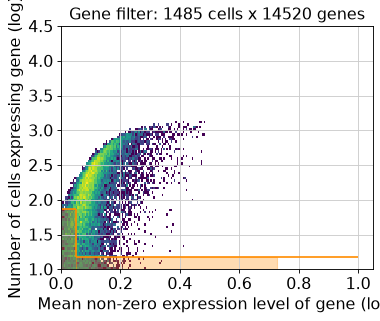

In [28]:
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel, Cell2location

shared = sorted(set(adata_ref.var_names) & set(adata.var_names))
ref = adata_ref[:, shared].copy()
vis = adata.copy()[:, shared].copy()

selected = filter_genes(ref, cell_count_cutoff=15, cell_percentage_cutoff2=0.05, nonz_mean_cutoff=1.12)
ref = ref[:, selected].copy()
vis = vis[:, [g for g in selected if g in vis.var_names]].copy()
print(f"Genes after filtering: {ref.n_vars}")

RegressionModel.setup_anndata(ref, layer="counts", batch_key="donor_id", labels_key="cell_type")
ref_model = RegressionModel(ref)
ref_model.train(max_epochs=REF_EPOCHS, batch_size=10000)
ref = ref_model.export_posterior(ref, sample_kwargs={"num_samples": 100, "batch_size": 10000})
inf_aver = ref.varm["q05_per_cluster_mu_fg"]
print(f"Reference signature: {inf_aver.shape} (genes x cell types)")

🔬 **TASK 5.3:** Train the spatial mapping model and export cell-type abundance per spot.

In [30]:
vis = vis[:, [g for g in inf_aver.index if g in vis.var_names]].copy()
inf_aver_aligned = inf_aver.loc[vis.var_names]

Cell2location.setup_anndata(vis, layer="counts", batch_key="sample_name" if "sample_name" in vis.obs else None)
sp_model = Cell2location(vis, cell_state_df=inf_aver_aligned, N_cells_per_location=30, detection_alpha=200)
sp_model.train(max_epochs=MAP_EPOCHS, batch_size=vis.n_obs)
vis = sp_model.export_posterior(vis, sample_kwargs={"num_samples": 100, "batch_size": vis.n_obs})

abundance = vis.obsm["q05_cell_abundance_w_sf"] if "q05_cell_abundance_w_sf" in vis.obsm else \
            vis.obs[[c for c in vis.obs.columns if c.startswith("q05")]]
print(f"Cell-type abundance per spot: {abundance.shape}")
print(abundance.describe().T[["mean", "std", "max"]].round(2))

/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/shared/projects/tp_2630_ubordeaux_neuromics_184418/envs/single_cell/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:321: The nu

🔬 **TASK 5.4:** Plot a few cell-type abundance maps on tissue.

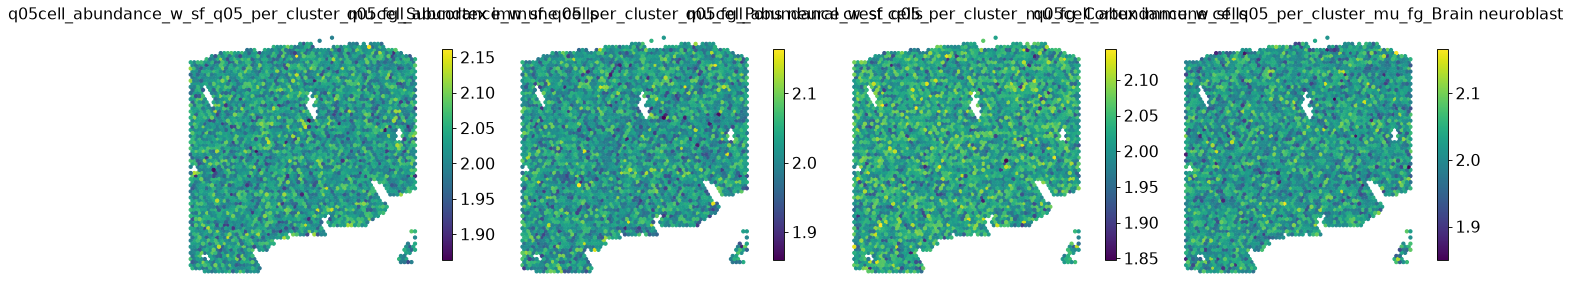

In [32]:
top_types = abundance.mean().nlargest(4).index.tolist()
fig, axes = plt.subplots(1, len(top_types), figsize=(4.2 * len(top_types), 4.2))
for ax, ct in zip(axes, top_types):
    vals = abundance[ct].to_numpy()
    coords = vis.obsm["spatial"]
    sca = ax.scatter(coords[:, 0], coords[:, 1], c=vals, cmap="viridis", s=8)
    ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_title(ct); ax.axis("off")
    fig.colorbar(sca, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

❓ **QUESTION:** Compare these deconvolved abundance maps to the blended Section 4 scores. Are the malignant-state spatial patterns sharper now? Does any region's *dominant* cell type surprise you given what the naive expression clustering (Section 3) suggested was there?

---

## 6. Spatial niches and intermixing

Individual cell-type abundances are noisy spot-by-spot. **NMF** on the abundance matrix finds
recurring *co-occurrence patterns* — niches — the way the original study does.

🔬 **TASK 6.1:** Run NMF on the cell2location abundance matrix with a few different factor counts.

In [35]:
from sklearn.decomposition import NMF

for n_factors in [5, 8, 12]:
    nmf = NMF(n_components=n_factors, init="nndsvda", random_state=0, max_iter=500)
    W = nmf.fit_transform(abundance.clip(lower=0))
    print(f"n_factors={n_factors}: reconstruction error = {nmf.reconstruction_err_:.1f}")
# Carry forward one choice for the rest of the notebook:
N_NICHES = 8
nmf = NMF(n_components=N_NICHES, init="nndsvda", random_state=0, max_iter=500)
niche_loadings = nmf.fit_transform(abundance.clip(lower=0))
vis.obs["niche"] = pd.Categorical(niche_loadings.argmax(axis=1).astype(str))
print(vis.obs["niche"].value_counts())

n_factors=5: reconstruction error = 8.4
n_factors=8: reconstruction error = 8.4
n_factors=12: reconstruction error = 8.2
niche
7    1952
6     965
5     514
4     238
3     138
2      61
1      33
0      27
Name: count, dtype: int64


🔬 **TASK 6.2:** Plot niches on tissue, and look at which cell types load most strongly onto each niche factor.

<cell 37>:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.


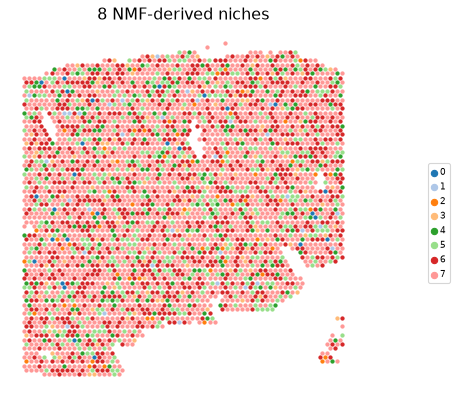

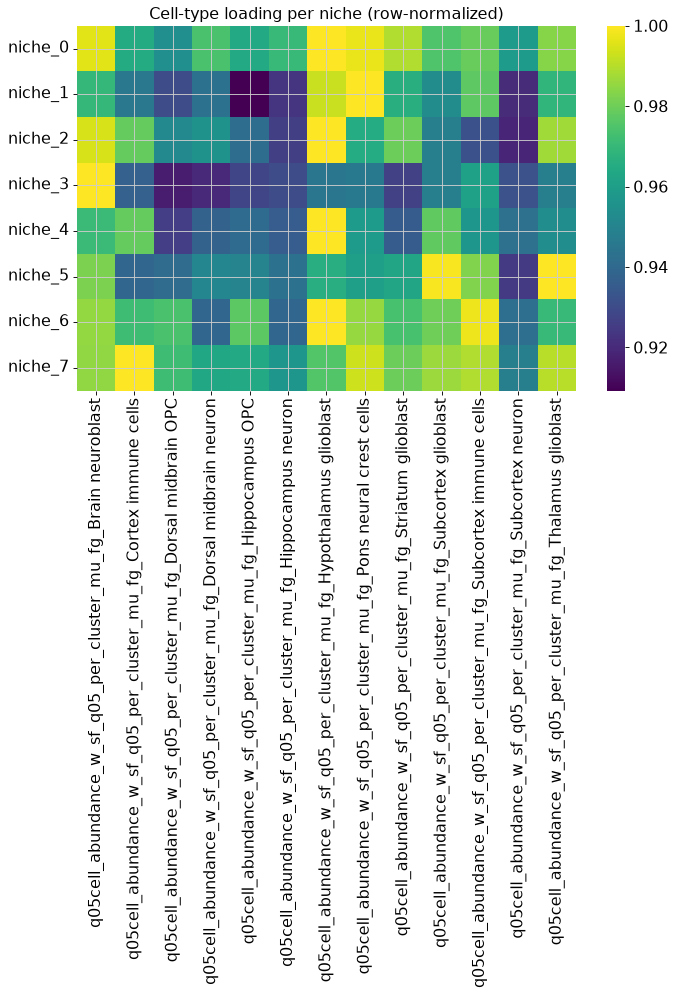

In [37]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_spatial_categories(vis, "niche", spatial_key="spatial")
plt.title(f"{N_NICHES} NMF-derived niches"); plt.show()

components = pd.DataFrame(nmf.components_, columns=abundance.columns,
                           index=[f"niche_{i}" for i in range(N_NICHES)])
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(components.div(components.max(axis=1), axis=0), cmap="viridis", ax=ax)
ax.set_title("Cell-type loading per niche (row-normalized)")
plt.tight_layout(); plt.show()

🔬 **TASK 6.3 — spatial intermixing.** For each spot, compute the Shannon entropy of its cell-type abundance distribution — a high-entropy spot has many cell types evenly mixed; a low-entropy spot is dominated by one.

<cell 39>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
niche
1    2.564584
2    2.564613
5    2.564615
6    2.564624
7    2.564647
4    2.564648
3    2.564660
0    2.564728
Name: intermixing_entropy, dtype: float32


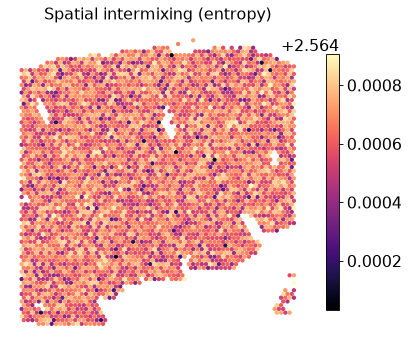

In [39]:
from scipy.stats import entropy

props = abundance.clip(lower=0)
props = props.div(props.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
vis.obs["intermixing_entropy"] = props.apply(lambda row: entropy(row + 1e-12), axis=1)

fig, ax = plt.subplots(figsize=(6, 6))
coords = vis.obsm["spatial"]
sca = ax.scatter(coords[:, 0], coords[:, 1], c=vis.obs["intermixing_entropy"], cmap="magma", s=8)
ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_title("Spatial intermixing (entropy)"); ax.axis("off")
fig.colorbar(sca, ax=ax, shrink=0.7); plt.show()
print(vis.obs.groupby("niche")["intermixing_entropy"].mean().sort_values())

❓ **QUESTION:** Which niche has the lowest intermixing entropy (most "pure")? Which has the highest? Does low entropy correspond to a niche you'd expect to be compositionally homogeneous (e.g. a dense malignant core) versus a mixed immune/stromal region?

---

## 7. Spatial neighborhood analysis, two ways

🔬 **TASK 7.1 — squidpy.** Build the spatial neighbor graph and compute neighborhood enrichment between niches.

In [42]:
sq.gr.spatial_neighbors(vis, coord_type="generic", n_neighs=6)
sq.gr.nhood_enrichment(vis, cluster_key="niche")
sq.pl.nhood_enrichment(vis, cluster_key="niche", figsize=(6, 5), annotate=False)

<cell 42>:1: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
INFO     Creating graph using `None` transform and `1` libraries.               
100%|##########| 1000/1000 [00:00<00:00, 1652.82/s]


🔬 **TASK 7.2 — the paper's own method.** Build the same kind of "which niches are near which" picture a different way: pairwise minimum spot-distance via a k-d tree, summarized at the 25th percentile (`gbmspace_utils.spatial_proximity_network` — this mirrors the paper's actual Fig. 2E/3C/6E/7E method, an alternative to squidpy's enrichment z-scores).

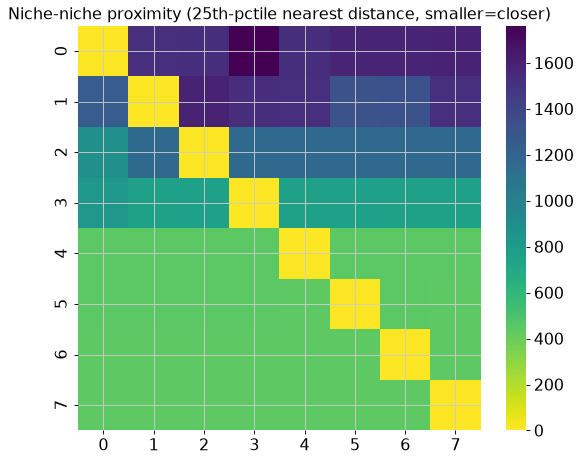

In [44]:
prox = spatial_proximity_network(vis, cluster_key="niche", spatial_key="spatial", percentile=25)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(prox, cmap="viridis_r", ax=ax)  # reversed: closer (smaller distance) = brighter
ax.set_title("Niche-niche proximity (25th-pctile nearest distance, smaller=closer)")
plt.tight_layout(); plt.show()

❓ **QUESTION:** Do squidpy's neighborhood-enrichment z-scores and the proximity-distance heatmap agree on which niches are spatial neighbors? Where (if anywhere) do they disagree, and why might two reasonable methods for "spatial closeness" give different answers?

---

## 8. (Optional / stretch) Cell-cell communication

This section is optional — only attempt it if Sections 1-7 are solid and you have time left.

The published study runs **LIANA** (a consensus of several ligand-receptor methods) comparing
TME states co-localized with dev-like niches vs. those co-localized with gliosis/hypoxia
niches. We skip their cross-donor Tensor-cell2cell step (not meaningful with only 2 donors).

🔬 **TASK 8.1 (optional):** Using your own niches from Section 6, define two spot groups —
"dev-like-dominant" and "gliosis/hypoxia-dominant" — and run LIANA's consensus scoring on
the corresponding cells in your Level 1 reference, comparing ligand-receptor activity between
the two groups.

In [47]:
# import liana as li
# (left for you to implement if you choose to attempt this section)
print("Optional section -- implement if time allows.")

Optional section -- implement if time allows.


## 9. Revealing the paper

📄 **de Jong, Memi, Gracia, Lazareva et al. "A spatiotemporal cancer cell trajectory
underlies glioblastoma heterogeneity." bioRxiv 2025.05.13.653495.** Companion website:
[gbmspace.org](https://www.gbmspace.org/). The data you have been working with (AT10 and
AT14, snRNA-seq + Visium) are two of the 12 IDH-wildtype glioblastoma tumours profiled in
this study (1,025,329 nuclei total across the cohort).

**Key findings, for comparison against your own results:**
- Malignant cells occupy a **continuous trajectory**, not discrete subtypes: from
  developmental-like states (OPC-like, NPC-neuronal-like, AC-progenitor-like) through a
  **gliosis** and **hypoxia** axis — what was historically called "mesenchymal-like" (MES1/2)
  in the Neftel et al. 2019 framework, but the authors show classical EMT regulators
  (`SNAI1/2`, `TWIST1/2`, `ZEB1/2`) are *not* specifically enriched there, arguing against an
  EMT interpretation.
- This trajectory maps onto **spatial zonation**: AC-progenitor-like cells dominate near the
  tumour core / infiltrating edge; gliosis and hypoxic states concentrate deep in the tumour,
  around and within necrotic regions — exactly the `AQP4` → `ABCC3` → `AKAP12` → `HILPDA`
  gradient you looked for in Section 4.
- Spatial **niches** were derived the same way you just did it: NMF on cell2location
  cell-state abundances (16 factors per tumour in the paper, clustered into ~14-16 recurrent
  niches across the cohort), cross-validated against pathologist-annotated IvyGAP regions
  (leading edge, infiltrating tumour, cellular tumour, necrosis, pseudopalisading cells,
  perinecrotic zone, microvascular proliferation).
- A major caveat the authors flag explicitly: **single-biopsy sampling can be misleading** —
  one of their tumours (AT10, the same donor in your data!) showed a different dominant
  malignant state in each of its 4 sampled sites, challenging the idea of one fixed
  "subtype" per tumour.

🔬 **TASK 9.1:** Now that you know the source, compare your own niche map and axis scores
against the paper'"'"'s actual cell2location/niche outputs for this exact section (these were
withheld from your input data — load them now from the answer-key file for comparison only).

In [49]:
answer_key = sc.read_h5ad("/shared/projects/tp_2630_ubordeaux_neuromics_184418/projects/C10/lederer/answer_keys/AT10-BRA-5-FO-1_2_answer_key.h5ad")
print(answer_key.var["feature_types"].value_counts())
# Compare e.g. answer_key[:, answer_key.var.feature_types=="Spatial niche abundances"]
# against your own `niche_loadings` / `vis.obs['niche']` -- do the spatial patterns line up?

feature_types
Cell state abundances           99
Spatial niche abundances        12
Histopath annotation overlap     7
Name: count, dtype: int64


❓ **QUESTION:** Where does your independent analysis agree with the published result, and where does it diverge? For any divergence, what's your best hypothesis — different gene filtering, different epoch budget (FAST vs FULL), different niche factor count, or something about how the reference was built in Level 1?

---

## 10. Write-up

🔬 **TASK 10.1:** Reproduce one specific published figure panel using your own pipeline, and write a short paragraph comparing your result to the original.

In [51]:
# Your figure-reproduction code here.

## Summary

You have:
1. ✅ QC'd and explored real Visium spatial data
2. ✅ Built a naive (pre-deconvolution) spatial domain map
3. ✅ Seen the malignant cell-state axis directly in space
4. ✅ Mapped your Level 1 reference onto tissue with **cell2location**
5. ✅ Identified spatial niches via NMF, and quantified spatial intermixing
6. ✅ Compared two methods for spatial neighborhood/proximity analysis
7. ✅ Compared your independent results against the published findings

**Further reading, not built here:** the paper also describes **spaceTree** (joint cell-type
+ genetic-clone mapping) and **cell2fate** (RNA-velocity-based temporal ordering of malignant
states) — both require data/pipelines beyond this course's current scope (paired snATAC-seq
clone-calling, and spliced/unspliced counts, respectively).